 **source** ="https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"

The dataset the IMDB Dataset of 50K Movie Reviews. It contains 50,000 reviews and two columns: review and sentiment; the labels are binary positive/negative
our main objective is to take reviews as input and sentiment as target variable and then prepare a model which is able to predict wheather the reviews
are positive or negative.
this is supervised learning binary classification problem. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import time
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)




In [2]:
df=pd.read_csv(r"C:\Users\victus\Downloads\archive (6).zip")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.describe().T

,count,unique,top,freq
review,50000,49582,Loved today's show!!! It was a variety and not...,5
sentiment,50000,2,positive,25000


In [7]:
df.describe(include="all")


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [8]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [9]:
df["sentiment"].unique()

array(['positive', 'negative'], dtype=object)

<Axes: xlabel='sentiment'>

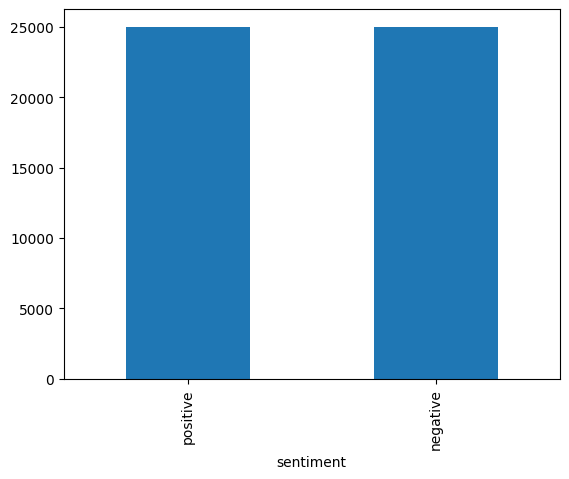

In [10]:
df["sentiment"].value_counts().plot(kind='bar')

no sign of target imbalanced cause both classes have equal data distribution

In [11]:
pd.set_option("display.max_colwidth", 500)

df.head(10)

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is calle...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly wr...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />T...",positive
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ru...",negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people in the different situations we encounter. <br /><br />This being a variation on the Arthur Schnitzler's play about the same theme, the director transfers the action to the present time New York where all these different characters meet and connect. Each one is conne...",positive
5,"Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never gets old, despite my having seen it some 15 or more times in the last 25 years. Paul Lukas' performance brings tears to my eyes, and Bette Davis, in one of her very few truly sympathetic roles, is a delight. The kids are, as grandma says, more like ""dressed-up midgets"" than children, but that only makes them more fun to watch. And the mother's...",positive
6,I sure would like to see a resurrection of a up dated Seahunt series with the tech they have today it would bring back the kid excitement in me.I grew up on black and white TV and Seahunt with Gunsmoke were my hero's every week.You have my vote for a comeback of a new sea hunt.We need a change of pace in TV and this would work for a world of under water adventure.Oh by the way thank you for an outlet like this to view many viewpoints about TV and the many movies.So any ole way I believe I've...,positive
7,"This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show was not really funny anymore, and it's continued its decline further to the complete waste of time it is today.<br /><br />It's truly disgraceful how far this show has fallen. The writing is painfully bad, the

from this i analyzed the insight that the reviews contains unnecessary spaces, html tags and urls .these things are not necessary and can effect our model . so we use feature engineering process to normalize this.

In [12]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(418)

In [14]:
df["review"].duplicated().sum()

np.int64(418)

In [15]:
df[df["review"].duplicated(keep=False)].sort_values("review").head(10)

,review,sentiment
34058,"""Go Fish"" garnered Rose Troche rightly or wrongly the reputation of a film maker with much promise.<br /><br />Its then hard to understand how she could turn out a movie made up of stereotypes that one associates with inferior sitcoms. The entire film rings hollow. I cringed the whole way through.<br /><br />Its supposed to be a look into nineties human sexuality. Well not much more here to be learned than from ""In and Out"". By now most of us actually do know, that there are men who are sexu...",negative
47467,"""Go Fish"" garnered Rose Troche rightly or wrongly the reputation of a film maker with much promise.<br /><br />Its then hard to understand how she could turn out a movie made up of stereotypes that one associates with inferior sitcoms. The entire film rings hollow. I cringed the whole way through.<br /><br />Its supposed to be a look into nineties human sexuality. Well not much more here to be learned than from ""In and Out"". By now most of us actually do know, that there are men who are sexu...",negative
29956,"""Three"" is a seriously dumb shipwreck movie. Masquerading as a psychological thriller, it's closest relative is the monumentally superior ""Dead Calm"" (also featuring Billy Zane). ""Dead Calm"" provided well drawn characters to root for in the form of Sam Neil and Nicole Kidman's grieving parents attempting to re-define their relationship on an ocean cruise. They end up being terrorised by Zane's adrift psycho-killer. It provided sharp, increasingly ratcheted suspense, a scary feeling of claust...",negative
31488,"""Three"" is a seriously dumb shipwreck movie. Masquerading as a psychological thriller, it's closest relative is the monumentally superior ""Dead Calm"" (also featuring Billy Zane). ""Dead Calm"" provided well drawn characters to root for in the form of Sam Neil and Nicole Kidman's grieving parents attempting to re-define their relationship on an ocean cruise. They end up being terrorised by Zane's adrift psycho-killer. It provided sharp, increasingly ratcheted suspense, a scary feeling of claust...",negative
47527,"""Witchery"" might just be the most incoherent and lamentably scripted horror movie of the 80's but, luckily enough, it has a few compensating qualities like fantastic gore effects, an exhilarating musical score and some terrific casting choices. Honestly the screenplay doesn't make one iota of sense, but who cares when Linda Blair (with an exploded hairstyle) portrays yet another girl possessed by evil powers and David Hasselhof depicts a hunky photographer (who can't seem to get laid) in a m...",negative
2976,"""Witchery"" might just be the most incoherent and lamentably scripted horror movie of the 80's but, luckily enough, it has a few compensating qualities like fantastic gore effects, an exhilarating musical score and some terrific casting choices. Honestly the screenplay doesn't make one iota of sense, but who cares when Linda Blair (with an exploded hairstyle) portrays yet another girl possessed by evil powers and David Hasselhof depicts a hunky photographer (who can't seem to get laid) in a m...",negative
7949,"'Dead Letter Office' is a low-budget film about a couple of employees of the Australian postal service, struggling to rebuild their damaged lives. Unfortunately, the acting is poor and the links between the characters' past misfortunes and present mindsets are clumsily and over-schematically represented. What's most disappointing of all, however, is the portrayal is life in the office of the film's title: there's no mechanisation whatsoever, and it's quite impossible to ascertain what any of...",negative
32260,"'Dead Letter Office' is a low-budget film about a couple of employees of the Australian postal service, struggling to rebuild their damaged lives. Unfortunately, the acting is poor and the links between the characters' past misfortunes and present mindsets are clumsily and over-schematically represented. What's most disappointing of

duplicated values as we can see

In [16]:
df["char_count"] = df["review"].str.len()

df["word_count"] = df["review"].str.split().str.len()

In [17]:
df[["char_count", "word_count"]].describe()

,char_count,word_count
count,50000.000000,50000.000000
mean,1309.431020,231.156940
std,989.728014,171.343997
min,32.000000,4.000000
25%,699.000000,126.000000
50%,970.000000,173.000000
75%,1590.250000,280.000000
max,13704.000000,2470.000000


In [18]:
df.head()

,review,sentiment,char_count,word_count
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is calle...",positive,1761,307
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly wr...",positive,998,162
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />T...",positive,926,166
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ru...",negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what money, power and success do to people in the different situations we encounter. <br /><br />This being a variation on the Arthur Schnitzler's play about the same theme, the director transfers the action to the present time New York where all these different characters meet and connect. Each one is conne...",positive,1317,230


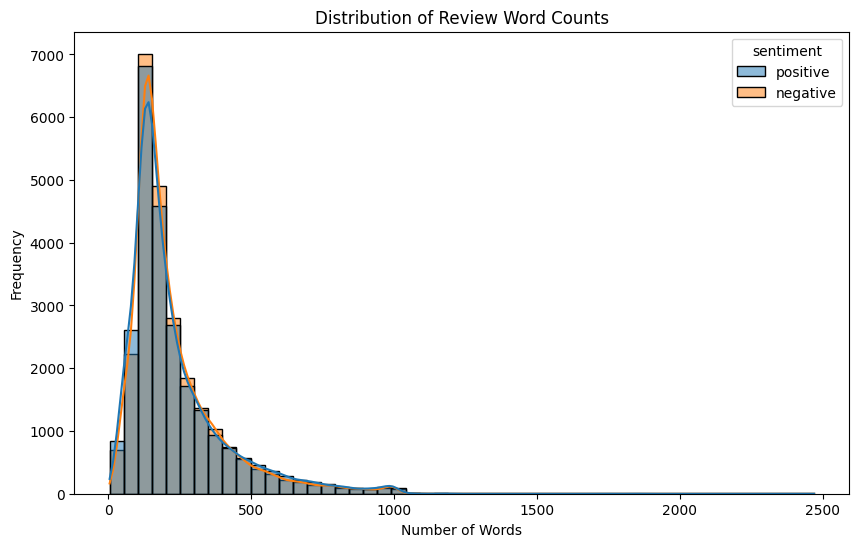

In [19]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="word_count",
    hue="sentiment",
    bins=50,
    kde=True
)

plt.title("Distribution of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

Most reviews are short — the bulk of the data is packed between roughly 50–300 words, with a sharp peak around 100–150 words. A long thin tail stretches out to 2000+ words. This is a classic right-skewed distribution — mean word count is pulled well above the median by a few very long reviews|

The blue (positive) and orange (negative) distributions overlap heavily and follow the same general curve. This suggests review length alone isn't a strong differentiator of sentiment — people don't write meaningfully longer or shorter reviews based on whether their opinion was positive or negative.

In [20]:
df.groupby("sentiment")[["char_count", "word_count"]].agg(
    ["mean", "median", "std", "min", "max"]
)

char_count                                word_count         \
                 mean median          std min    max       mean median   
sentiment                                                                
negative   1294.06436  973.0   945.892669  32   8969  229.46456  174.0   
positive   1324.79768  968.0  1031.492627  65  13704  232.84932  172.0   

                                 
                  std min   max  
sentiment                        
negative   164.947795   4  1522  
positive   177.497046  10  2470

In [21]:
df["word_count"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01     42.0
0.05     63.0
0.25    126.0
0.50    173.0
0.75    280.0
0.95    590.0
0.99    908.0
Name: word_count, dtype: float64

In [22]:
df.nsmallest(20, "word_count")[["review", "sentiment", "word_count"]]

,review,sentiment,word_count
28920,Primary plot!Primary direction!Poor interpretation.,negative,4
27521,"Read the book, forget the movie!",negative,6
13109,"More suspenseful, more subtle, much, much more disturbing....",negative,8
40817,I hope this group of film-makers never re-unites.,negative,8
31072,"What a script, what a story, what a mess!",negative,9
11926,I wouldn't rent this one even on dollar rental night.,negative,10
18400,Brilliant and moving performances by Tom Courtenay and Peter Finch.,positive,10
19874,This movie is terrible but it has some good effects.,negative,10
20274,You'd better choose Paul Verhoeven's even if you have watched it.,negative,11
31761,Ming The Merciless does a little Bardwork and a movie most foul!,negative,12


In [23]:
df.nlargest(10, "word_count")[["review", "sentiment", "word_count"]]

,review,sentiment,word_count
31481,"Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried t...",positive,2470
40521,"There's a sign on The Lost Highway that says:<br /><br />*MAJOR SPOILERS AHEAD*<br /><br />(but you already knew that, didn't you?)<br /><br />Since there's a great deal of people that apparently did not get the point of this movie, I'd like to contribute my interpretation of why the plot makes perfect sense. As others have pointed out, one single viewing of this movie is not sufficient. If you have the DVD of MD, you can ""cheat"" by looking at David Lynch's ""Top 10 Hints to Unlocking MD"" (bu...",positive,2278
31436,"Back in the mid/late 80s, an OAV anime by title of ""Bubblegum Crisis"" (which I think is a military slang term for when technical equipment goes haywire) made its debut on video, taking inspiration from ""Blade Runner"", ""The Terminator"" and maybe even ""Robocop"", with a little dash of Batman/Bruce Wayne - Iron Man/Tony Stark and Charlie's Angel's girl power thrown in for good measure. 8 episodes long, the overall story was that in 21st century Tokyo, Japan, year 2032-2033, living machines calle...",positive,2125
31240,"(Some spoilers included:)<br /><br />Although, many commentators have called this film surreal, the term fits poorly here. To quote from Encyclopedia Britannica's, surreal means:<br /><br />""Fantastic or incongruous imagery"": One needn't explain to the unimaginative how many ways a plucky ten-year-old boy at large and seeking his fortune in the driver's seat of a red Mustang could be fantastic: those curious might read James Kincaid; but if you asked said lad how he were incongruous behind t...",positive,2108
12647,"Titanic directed by James Cameron presents a fictional love story on the historical setting of the Titanic. The plot is simple, noncomplicated, or not for those who love plots that twist and turn and keep you in suspense. The end of the movie can be figured out within minutes of the start of the film, but the love story is an interesting one, however. Kate Winslett is wonderful as Rose, an aristocratic young lady betrothed by Cal (Billy Zane). Early on the voyage Rose meets Jack (Leonardo Di...",positive,1839
5708,"**Attention Spoilers**<br /><br />First of all, let me say that Rob Roy is one of the best films of the 90's. It was an amazing achievement for all those involved, especially the acting of Liam Neeson, Jessica Lange, John Hurt, Brian Cox, and Tim Roth. Michael Canton Jones painted a wonderful portrait of the honor and dishonor that men can represent in themselves. But alas...<br /><br />it constantly, and unfairly gets compared to ""Braveheart"". These are two entirely different films, probabl...",positive,1830
3024,"If anyone ever assembles a compendium on modern American horror that is truly worth it's salt, there will *have* to be an entry for SF Brownrigg's ubiquetous exercize in Asylum Horror. Every time I watch this movie I am impressed by the complete economy of the film, from the compact, totally self-contained plot with a puzzling beginning and an all too horrible ending, the engaging performances by what was essentially a group of non-professional actors, and a prevading sense of dread and clau...",positive,1737
42946,"By now you've probably heard a bit about the new Disney dub of Miyazaki's classic film, Laputa: Castle In The Sky. During late summer of 1998, Disney released ""Kiki's Delivery Service"" on video which included a preview of the Laputa dub saying it was due out in ""1999"". It's obviously way pas

In [24]:
def clean_text(text):
    
    # Convert to string
    text = str(text)
    
    # Remove HTML
    text = BeautifulSoup(text, "html.parser").get_text(" ")
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    
    # Normalize whitespace
    text = re.sub(r"\s+", " ", text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    return text

In [25]:
df["clean_review"] = df["review"].apply(clean_text)

C:\Users\victus\AppData\Local\Temp\ipykernel_18868\1155503688.py:7: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text(" ")


In [26]:
df[["review", "clean_review"]].head()

,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is calle...","one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word. it is called oz as that is the ni..."
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only ""has got all the polari"" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly wr...","a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. the actors are extremely well chosen- michael sheen not only ""has got all the polari"" but he has all the voices down pat too! you can truly see the seamless editing guided by the references to williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piec..."
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />T...","i thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. the plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). while some may be disappointed when they realize this is not match point 2: risk addiction, i thought it was proof that woody allen is still fully in control of the style many of us have grown to love. this was the..."
3,"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ru...","basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time. this movie is slower than a soap opera... and suddenly, jake decides to become rambo and kill the zombie. ok, first of all when you're going to make a film you must decide if its a thriller or a drama! as a drama the movie is watchable. parents are divorcing & arguing like in real life. and then we have jake with his c

# Remove Empty Reviews

In [27]:
df["clean_review"].str.len().describe()

count    50000.00000
mean      1286.76798
std        972.38092
min         32.00000
25%        690.00000
50%        954.00000
75%       1561.00000
max      13593.00000
Name: clean_review, dtype: float64

In [28]:
(df["clean_review"].str.strip() == "").sum()

np.int64(0)

it says 0 means after cleaning none of the reviews become empty every row has still some meaningfull content left.so we dont have to delete 

# Remove Exact Duplicates

In [29]:
df.duplicated(subset=["clean_review"]).sum()

np.int64(422)

In [30]:
before = len(df)

df = df.drop_duplicates(subset=["clean_review"]).reset_index(drop=True)

after = len(df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 50000
Rows after: 49578
Duplicates removed: 422


# encode target

In [31]:
df["target"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

In [32]:
df["target"].value_counts()

target
1    24882
0    24696
Name: count, dtype: int64

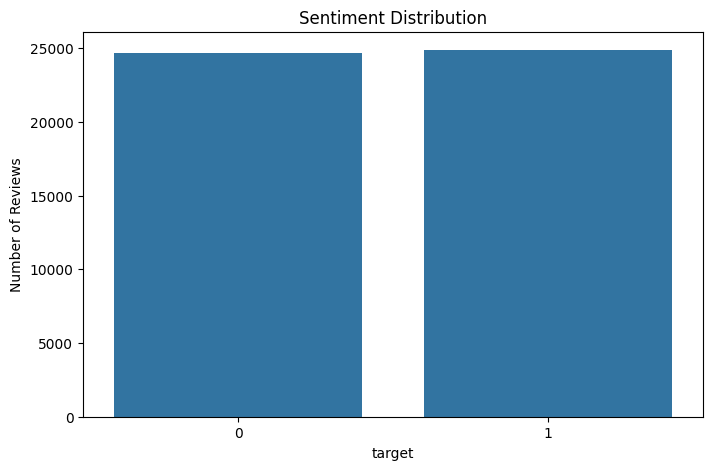

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="target"
)

plt.title("Sentiment Distribution")
plt.xlabel("target")
plt.ylabel("Number of Reviews")

plt.show()

In [34]:
X = df["clean_review"]
y = df["target"]

In [35]:
X.shape,y.shape

((49578,), (49578,))

seperate x and y

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

split the data into training and testing step

In [37]:
X_train.shape,X_test.shape


((39662,), (9916,))

In [38]:
print("Training:", y_train.shape)
print("Testing :", X_test.shape)

Training: (39662,)
Testing : (9916,)


# using vectorizer to convert text to numric features and building pipeline with multiple models

In [39]:
lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [40]:
start = time.time()

lr_pipeline.fit(X_train, y_train)

lr_train_time = time.time() - start

print(f"Training time: {lr_train_time:.2f} seconds")

Training time: 26.94 seconds


In [41]:
lr_pred = lr_pipeline.predict(X_test)

In [42]:
lr_pipeline.score(X_test,y_test)*100

90.70189592577653

In [43]:
lr_pipeline.score(X_train,y_train)*100

94.96243255509052

In [45]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91      4939
    Positive       0.89      0.92      0.91      4977

    accuracy                           0.91      9916
   macro avg       0.91      0.91      0.91      9916
weighted avg       0.91      0.91      0.91      9916



# experiment 2 using naive bayes

In [46]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    
    ("classifier", MultinomialNB())
])

In [47]:
nb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=100000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier', MultinomialNB())])

In [48]:
nb_pred = nb_pipeline.predict(X_test)

In [50]:
nb_pipeline.score(X_test,y_test)*100,nb_pipeline.score(X_train,y_train)*100

(89.0278338039532, 91.89904694669961)

training and testing score almost same no sign of overfitting

In [49]:
print(classification_report(
    y_test,
    nb_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89      4939
    Positive       0.89      0.89      0.89      4977

    accuracy                           0.89      9916
   macro avg       0.89      0.89      0.89      9916
weighted avg       0.89      0.89      0.89      9916



# experiment 3 using linear svm

In [51]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    
    ("classifier", LinearSVC())
])

In [52]:
start = time.time()

svm_pipeline.fit(X_train, y_train)

svm_train_time = time.time() - start

In [53]:
svm_pred = svm_pipeline.predict(X_test)

In [55]:
svm_pipeline.score(X_test,y_test)*100,svm_pipeline.score(X_train,y_train)*100

(91.28680919725696, 99.86132822348847)

In [54]:
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      4939
    Positive       0.91      0.92      0.91      4977

    accuracy                           0.91      9916
   macro avg       0.91      0.91      0.91      9916
weighted avg       0.91      0.91      0.91      9916



# experiment 4 using sgd qualifier

In [63]:
sgd_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    
    ("classifier", SGDClassifier(
        loss="hinge",
        max_iter=100,
        random_state=42
    ))
])

In [64]:
sgd_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=100000, min_df=2,
                                 ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier', SGDClassifier(max_iter=100, random_state=42))])

In [65]:
sgd_pred = sgd_pipeline.predict(X_test)

In [66]:
sgd_pipeline.score(X_test,y_test)*100,sgd_pipeline.score(X_train,y_train)*100

(90.92375958047599, 94.77585598305683)

In [67]:
print(classification_report(
    y_test,
    sgd_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91      4939
    Positive       0.90      0.93      0.91      4977

    accuracy                           0.91      9916
   macro avg       0.91      0.91      0.91      9916
weighted avg       0.91      0.91      0.91      9916



from the above findings every model performs almost the same . so we can take any from that

# svm confusion matrix evaluation

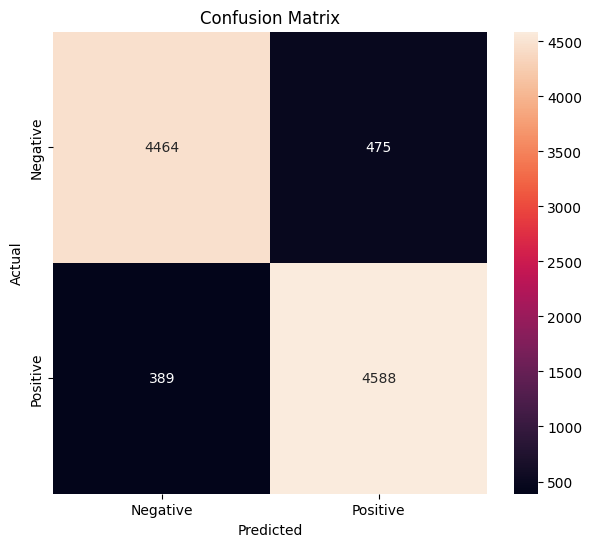

In [62]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

save any one model 

In [70]:
import joblib
import os
os.makedirs("models", exist_ok=True)

joblib.dump(
    svm_pipeline,
    "models/imdb_sentiment_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


# load the model

In [71]:
loaded_model = joblib.load(
    "models/imdb_sentiment_model.pkl"
)

# test positive review

In [73]:
test_review = """
This movie was absolutely fantastic.
The acting was brilliant and the story was very engaging.
"""

prediction = loaded_model.predict([test_review])[0]
if prediction == 1:
    print("Positive")
else:
    print("Negative")

Positive


the review is positive and the prediction ia also positive 

# test negative review

In [74]:
test_review = """
This was one of the worst movies I have ever watched.
The story was boring and the acting was terrible.
"""

prediction = loaded_model.predict([test_review])[0]

if prediction == 1:
    print("Positive")
else:
    print("Negative")

Negative


the review is negative and the prediction ia also negative 